# Raw Data — TopCV

In [ ]:
import pandas as pd

# Hiển thị toàn bộ nội dung của mỗi cell
pd.set_option('display.max_colwidth', None)

# Hiển thị tất cả cột
pd.set_option('display.max_columns', None)

# Tăng chiều rộng hiển thị
pd.set_option('display.width', None)

# Hiển thị toàn bộ chiều rộng DataFrame
pd.set_option('display.expand_frame_repr', False)

In [ ]:
df = pd.read_csv("../../data/raw/00-topcv_raw.csv")

In [4]:
import pandas as pd
import numpy as np
import re

def thong_ke_missing_data(df):
    """
    Hàm thống kê dữ liệu thiếu dựa trên các điều kiện đặc thù:
    - Salary: Không có số = Missing
    - Skills: [] hoặc '[]' = Missing
    - Các cột khác: NaN hoặc chuỗi rỗng = Missing
    """
    df_temp = df.copy()
    
    # 1. Hàm kiểm tra salary (phải chứa ít nhất 1 chữ số)
    def check_salary_missing(val):
        if pd.isna(val): return True
        return not bool(re.search(r'\d', str(val)))
        
    # 2. Hàm kiểm tra mảng kỹ năng (list rỗng hoặc string '[]')
    def check_empty_array(val):
        if isinstance(val, list):
            return len(val) == 0
        if isinstance(val, str):
            return val.strip() in ['[]', "['']", '[""]', '']
        return pd.isna(val)

    # 3. Hàm kiểm tra các cột văn bản thông thường (NaN, rỗng, hoặc chỉ có khoảng trắng)
    def check_general_missing(val):
        if pd.isna(val): return True
        if isinstance(val, str) and val.strip() == '': return True
        return False

    # Duyệt qua từng cột trong DataFrame của bạn
    for col in df_temp.columns:
        if col == 'salary':
            df_temp[col] = df_temp[col].apply(lambda x: np.nan if check_salary_missing(x) else x)
        elif col in ['required_skills', 'preferred_skills']:
            df_temp[col] = df_temp[col].apply(lambda x: np.nan if check_empty_array(x) else x)
        else:
            # Áp dụng cho job_title, company, location, experience, etc.
            df_temp[col] = df_temp[col].apply(lambda x: np.nan if check_general_missing(x) else x)
            
    # Tính toán con số cuối cùng
    total_rows = len(df_temp)
    missing_counts = df_temp.isnull().sum()
    missing_percentages = (missing_counts / total_rows) * 100
    
    # Tạo bảng kết quả
    ket_qua = pd.DataFrame({
        'Số lượng thiếu': missing_counts,
        'Tỷ lệ (%)': missing_percentages.round(2)
    })
    
    # Sắp xếp theo tỷ lệ giảm dần và chỉ hiện các cột có thiếu dữ liệu
    ket_qua = ket_qua[ket_qua['Số lượng thiếu'] > 0].sort_values(by='Tỷ lệ (%)', ascending=False)
    
    return ket_qua

stats = thong_ke_missing_data(df)
print(stats)

                  Số lượng thiếu  Tỷ lệ (%)
preferred_skills            2988      68.16
salary                      1890      43.11
required_skills             1785      40.72
industry                     281       6.41
employment_type              276       6.30
experience                   276       6.30
company                      276       6.30
education                    276       6.30
job_description              276       6.30
level                        276       6.30
requirement                  276       6.30
location                       8       0.18


In [5]:
df.shape

(4384, 15)

## Raw Data — ITViec

In [ ]:
try:
    df_itviec_raw = pd.read_csv("../../data/raw/00-itviec_raw.csv")
    print(f"ITViec raw: {df_itviec_raw.shape}")
    stats_itviec = thong_ke_missing_data(df_itviec_raw)
    print(stats_itviec)
except FileNotFoundError:
    print("00-itviec_raw.csv not found — data chưa có chính thức, skip.")

# Xử lý job title

In [ ]:
import sys, pathlib, importlib.util

_main_dir = pathlib.Path().resolve() / "main"
for _alias, _file in [
    ("title_filter",     "03_title_filter.py"),
    ("title_normalizer", "03_title_normalizer.py"),
    ("salary_utils",     "03_salary_utils.py"),
]:
    _spec = importlib.util.spec_from_file_location(_alias, _main_dir / _file)
    _mod  = importlib.util.module_from_spec(_spec)
    sys.modules[_alias] = _mod
    _spec.loader.exec_module(_mod)

from title_filter import filter_by_standardized_title   # type: ignore[import]
from title_normalizer import normalize_titles            # type: ignore[import]
from salary_utils import add_salary_flags, get_valid_salary_mask  # type: ignore[import]

In [ ]:
import pandas as pd

df_topcv = pd.read_csv("output/01-topcv_llm_standardized.csv")
df_topcv["source"] = "topcv"
print(f"TopCV LLM standardized: {len(df_topcv):,} rows")

In [ ]:
try:
    df_itviec = pd.read_csv("output/01-itviec_llm_standardized.csv")
    df_itviec["source"] = "itviec"
    print(f"ITViec LLM standardized: {len(df_itviec):,} rows")
    ITVIEC_AVAILABLE = True
except FileNotFoundError:
    print("output/01-itviec_llm_standardized.csv not found — chạy 01_process_job_title.py --dataset itviec rồi 02_merge_job_title.py --dataset itviec trước.")
    df_itviec = None
    ITVIEC_AVAILABLE = False

In [ ]:
import pandas as pd

frames = [df_topcv]
if ITVIEC_AVAILABLE:
    frames.append(df_itviec)

df = pd.concat(frames, ignore_index=True)

src_counts = df["source"].value_counts().to_dict()
summary = ", ".join(f"{s}={c:,}" for s, c in src_counts.items())
print(f"Merged: {len(df):,} rows ({summary})")

In [2]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# =========================
# TITLE STATS
# =========================
title_counts = df['standardized_title'].value_counts()

title_percentages = (
    df['standardized_title']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

job_title_stats = pd.DataFrame({
    'count': title_counts,
    'percentage': title_percentages,
})

# =========================
# SAMPLE DESCRIPTION
# ONLY FOR COUNT = 1
# =========================
single_titles = set(
    job_title_stats[
        job_title_stats['count'] == 1
    ].index
)

sample_descriptions = (
    df[
        df['standardized_title'].isin(single_titles)
    ]
    .groupby('standardized_title')['job_description']
    .first()
)

# =========================
# MERGE
# =========================
job_title_stats['sample_description'] = (
    sample_descriptions
)

job_title_stats = (
    job_title_stats
    .reset_index()
    .rename(columns={'index': 'standardized_title'})
)

# =========================
# SAVE
# =========================
job_title_stats.to_csv(
    "../../data/interim/job_title_stats.csv",
    index=False,
    encoding="utf-8-sig"
)

print(job_title_stats.head())

  standardized_title  count  percentage sample_description
0   Graphic Designer    771       21.57                NaN
1  Backend Developer    225        6.29                NaN
2   Business Analyst    214        5.99                NaN
3         IT Support    155        4.34                NaN
4        QA Engineer    154        4.31                NaN


In [ ]:
samples = df[
    df['standardized_title']
    .str.strip()
    .str.lower()
    .eq('customer success')
][[
    'source',
    'job_title',
    'standardized_title',
    'job_description'
]]

samples = samples.sample(
    n=min(5, len(samples)),
    random_state=42
)

for i, row in samples.iterrows():
    print("=" * 100)
    print(f"SOURCE          : {row['source']}")
    print(f"JOB TITLE       : {row['job_title']}")
    print(f"STANDARDIZED    : {row['standardized_title']}")
    print(f"\nJOB DESCRIPTION :\n{str(row['job_description'])[:3000]}")
    print()

In [ ]:
df_filtered, df_dropped = filter_by_standardized_title(df)

print(f"Original rows : {len(df):,}")
print(f"Filtered rows : {len(df_filtered):,}")
print(f"Dropped rows  : {len(df_dropped):,}")
print()
print("Breakdown by source after filter:")
print(df_filtered["source"].value_counts().to_string())

In [ ]:
df_filtered = normalize_titles(df_filtered)
print("Titles normalized.")

In [6]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# =========================
# TITLE STATS
# =========================
title_counts = df_filtered['standardized_title'].value_counts()

title_percentages = (
    df_filtered['standardized_title']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

job_title_stats = pd.DataFrame({
    'count': title_counts,
    'percentage': title_percentages,
})

# =========================
# SAMPLE DESCRIPTION
# ONLY FOR COUNT = 1
# =========================
single_titles = set(
    job_title_stats[
        job_title_stats['count'] == 1
    ].index
)

sample_descriptions = (
    df_filtered[
        df_filtered['standardized_title'].isin(single_titles)
    ]
    .groupby('standardized_title')['job_description']
    .first()
)

# =========================
# MERGE
# =========================
job_title_stats['sample_description'] = (
    sample_descriptions
)

job_title_stats = (
    job_title_stats
    .reset_index()
    .rename(columns={'index': 'standardized_title'})
)

# =========================
# SAVE
# =========================
job_title_stats.to_csv(
    "../../data/interim/job_title_stats.csv",
    index=False,
    encoding="utf-8-sig"
)

print(job_title_stats.head())

  standardized_title  count  percentage sample_description
0        QA Engineer    237        9.89                NaN
1  Backend Developer    225        9.39                NaN
2   Business Analyst    214        8.93                NaN
3         IT Support    169        7.05                NaN
4    Project Manager    123        5.13                NaN


In [7]:
df_filtered.shape

(3205, 17)

In [ ]:
df_filtered = add_salary_flags(df_filtered)

result = (
    df_filtered.groupby("standardized_title")
    .agg(
        total=("salary", "size"),
        missing_salary_count=("is_missing_salary", "sum"),
        missing_salary_pct=("is_missing_salary", "mean"),
    )
    .reset_index()
)
result["missing_salary_pct"] *= 100
result = result.sort_values("total", ascending=False)
result

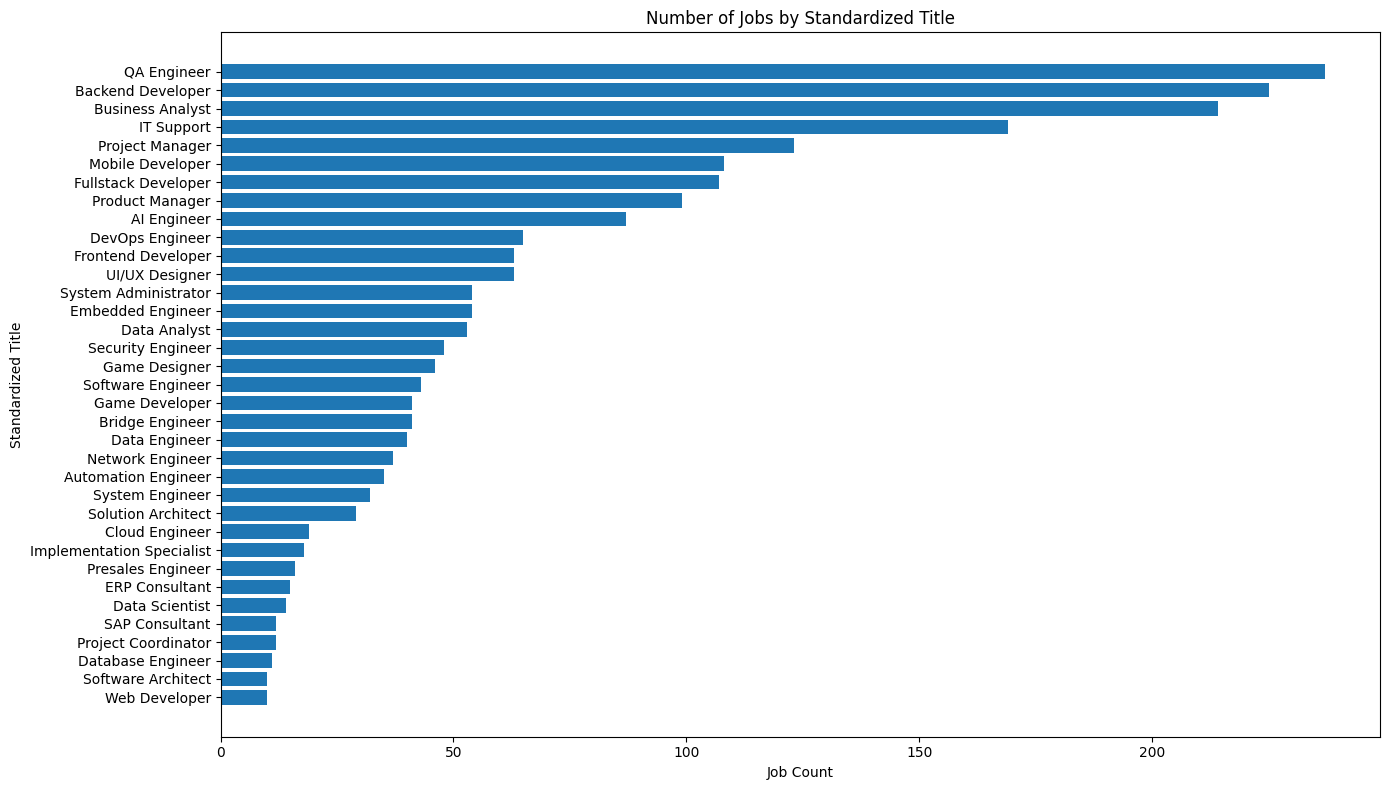

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# COUNT JOBS BY TITLE
# =========================

result = (
    df_filtered.groupby("standardized_title")
    .size()
    .reset_index(name="count")
)

# chỉ lấy title có >= 10 dòng
plot_df = result[
    result["count"] >= 10
].sort_values(
    "count",
    ascending=False
)

# =========================
# VISUALIZE
# =========================

plt.figure(figsize=(14, 8))

plt.barh(
    plot_df["standardized_title"],
    plot_df["count"]
)

plt.xlabel("Job Count")
plt.ylabel("Standardized Title")
plt.title("Number of Jobs by Standardized Title")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

is_valid_salary = get_valid_salary_mask(df_filtered)
df_valid = df_filtered[is_valid_salary].copy()

result = (
    df_valid.groupby("standardized_title")
    .size()
    .reset_index(name="valid_salary_count")
)

plot_df = result[result["valid_salary_count"] >= 10].sort_values(
    "valid_salary_count", ascending=False
)

plt.figure(figsize=(14, 10))
bars = plt.barh(plot_df["standardized_title"], plot_df["valid_salary_count"])
for i, v in enumerate(plot_df["valid_salary_count"]):
    plt.text(v + 1, i, str(v), va="center")
plt.xlabel("Valid Salary Count")
plt.ylabel("Standardized Title")
plt.title("Number of Valid Salaries by Standardized Title")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
import os

INTERIM = "../../data/interim"
os.makedirs(INTERIM, exist_ok=True)

DROP_COLS = ["is_valid_job", "is_null_salary", "is_thoa_thuan", "is_missing_salary"]

df_out = (
    df_filtered[df_filtered["is_valid_job"].astype(str).str.lower() != "false"]
    .drop(columns=[c for c in DROP_COLS if c in df_filtered.columns])
    .copy()
)

# --- TopCV ---
df_topcv_out = df_out[df_out["source"] == "topcv"].drop(columns=["source"]).copy()
topcv_path = f"{INTERIM}/02-topcv_standardized_title.csv"
df_topcv_out.to_csv(topcv_path, index=False, encoding="utf-8-sig")
print(f"Saved TopCV  : {len(df_topcv_out):,} rows → {topcv_path}")

# --- ITViec ---
if ITVIEC_AVAILABLE:
    df_itviec_out = df_out[df_out["source"] == "itviec"].drop(columns=["source"]).copy()
    itviec_path = f"{INTERIM}/02-itviec_standardized_title.csv"
    df_itviec_out.to_csv(itviec_path, index=False, encoding="utf-8-sig")
    print(f"Saved ITViec : {len(df_itviec_out):,} rows → {itviec_path}")
else:
    print("ITViec: skipped (data not yet available)")